# Feature Extraction

Demonstrates patch-level feature extraction and text-conditioned semantic queries using the `collab_splats.semantics` module.

Two extractors are shown:
- **MaskCLIP** (`"maskclip"`) — patch CLIP features via `maskclip_onnx`
- **Talk2DINO** (`"talk2dino"`) — DINOv3 + CLIP projection, text queries via HuggingFace Hub

Each section: load extractor → extract features → visualize (PCA RGB | similarity heatmap | masked image).

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
%matplotlib inline

from collab_splats.semantics.features import (
    BaseFeatureExtractor,
    MaskCLIPExtractor,
    Talk2DinoExtractor,
)
from collab_splats.utils.visualization import pca_to_rgb, compute_heatmap, compute_masked_image

print("Registered extractors:", list(BaseFeatureExtractor._registry.keys()))

/opt/conda/envs/nerfstudio/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/opt/conda/envs/nerfstudio/lib/python3.11/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/opt/conda/envs/nerfstudio/lib/python3.11/site-packages/mobile_sam/modeling/tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_5m_224 in registry with mobile_sam.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/opt/conda/envs/nerfstudio/lib/python3.11/site-packages/mobile_sam/mod

Registered extractors: ['maskclip', 'dinov2', 'talk2dino']


Loaded frame: 000001.jpg  shape=(1920, 1080, 3)


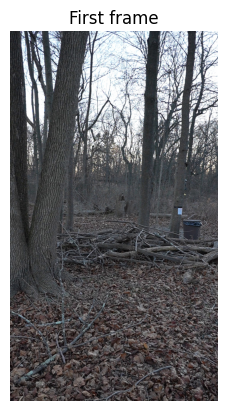

In [3]:
# ── Configuration ─────────────────────────────────────────────────────────────
DATASET   = "birds_c0043"
QUERIES   = ["tree", "bark"]
NEGATIVES = []

CACHE    = Path("../../.cache") / DATASET
IMAGES   = CACHE / "images"
FEATURES = CACHE / "semantics" / "features.zarr"
FEATURES.parent.mkdir(parents=True, exist_ok=True)

assert IMAGES.exists() and any(IMAGES.glob("*.jpg")), (
    f"No images in {IMAGES}. Run 01_preprocessing/keyframe_extraction first."
)

# Load first frame for feature extraction demo
frame_path = sorted(IMAGES.glob("*.jpg"))[0]
frame = np.array(Image.open(frame_path))
print(f"Loaded frame: {frame_path.name}  shape={frame.shape}")

plt.imshow(frame)
plt.axis("off")
plt.title("First frame")
plt.show()

## MaskCLIP

Patch-level CLIP features. Supports text query via `compute_similarity()`.

In [4]:
extractor_clip = MaskCLIPExtractor()
print("MaskCLIP loaded. Patch size:", extractor_clip.patch_size)

MaskCLIP loaded. Patch size: 14


In [5]:
# pil_frame = Image.fromarray(frame)
features_clip = extractor_clip.forward([frame])  # list of (C, pH, pW)
print("Feature shape:", features_clip[0].shape)  # e.g. (512, 24, 24)

Feature shape: torch.Size([768, 73, 41])


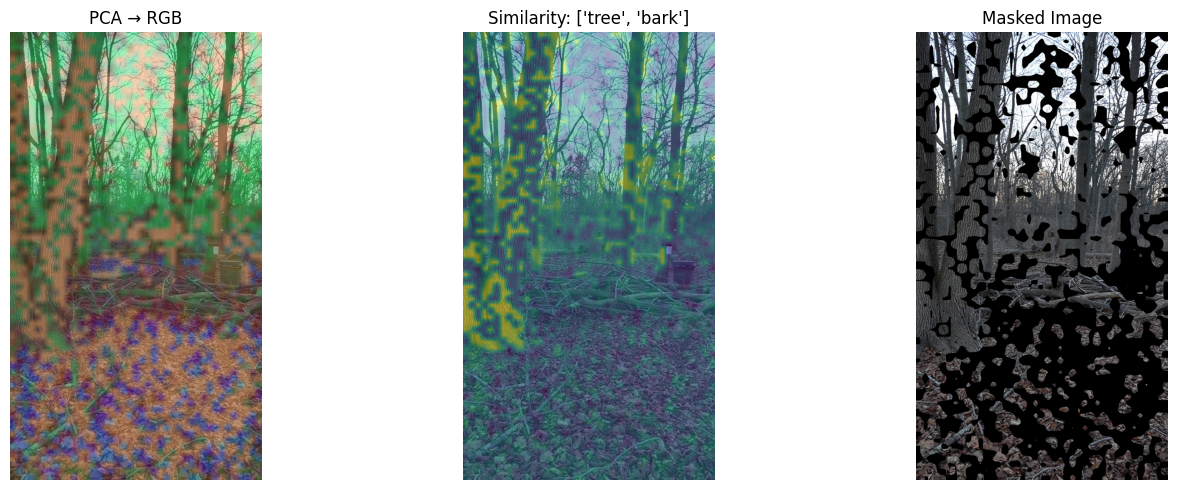

In [6]:
sim_map_clip = extractor_clip.score_queries(
    features_clip[0], positive=QUERIES,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(pca_to_rgb(features_clip[0], frame))
axes[0].set_title("PCA → RGB")
axes[1].imshow(compute_heatmap(frame, sim_map_clip))
axes[1].set_title(f"Similarity: {QUERIES}")
axes[2].imshow(compute_masked_image(frame, sim_map_clip))
axes[2].set_title("Masked Image")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Talk2DINO

DINOv3 backbone with CLIP text projection. Patch features + text-conditioned similarity.

`preprocess()` center-crops to square before `forward()` — required by Talk2DINO.

In [7]:
extractor_t2d = Talk2DinoExtractor(model_name="lorebianchi98/Talk2DINOv3-ViTB")
print("Talk2DINO loaded. Patch size:", extractor_t2d.patch_size)

/opt/conda/envs/nerfstudio/lib/python3.11/site-packages/torch/nn/modules/module.py:2068: UserWarning: for cls_token: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(f'for {key}: copying from a non-meta parameter in the checkpoint to a meta '
/opt/conda/envs/nerfstudio/lib/python3.11/site-packages/torch/nn/modules/module.py:2068: UserWarning: for reg_token: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(f'for {key}: copying from a non-meta parameter in the checkpoint to a meta '
/opt/conda/envs/nerfstudio/lib/python3.11/site-packa

/opt/conda/envs/nerfstudio/lib/python3.11/site-packages/torch/nn/modules/module.py:2068: UserWarning: for positional_embedding: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(f'for {key}: copying from a non-meta parameter in the checkpoint to a meta '
/opt/conda/envs/nerfstudio/lib/python3.11/site-packages/torch/nn/modules/module.py:2068: UserWarning: for text_projection: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(f'for {key}: copying from a non-meta parameter in the checkpoint to a meta '
/opt/conda/envs/nerfstudio/lib/pyth

Some weights of the model checkpoint at lorebianchi98/Talk2DINOv3-ViTB were not used when initializing Talk2DINO: ['pamr.aff_m.kernel', 'pamr.aff_std.kernel', 'pamr.aff_x.kernel']
- This IS expected if you are initializing Talk2DINO from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Talk2DINO from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Talk2DINO loaded. Patch size: 16


In [8]:
features_t2d = extractor_t2d.forward([frame])  # forward() center-crops internally
print("Feature shape:", features_t2d[0].shape)

Feature shape: torch.Size([768, 28, 28])


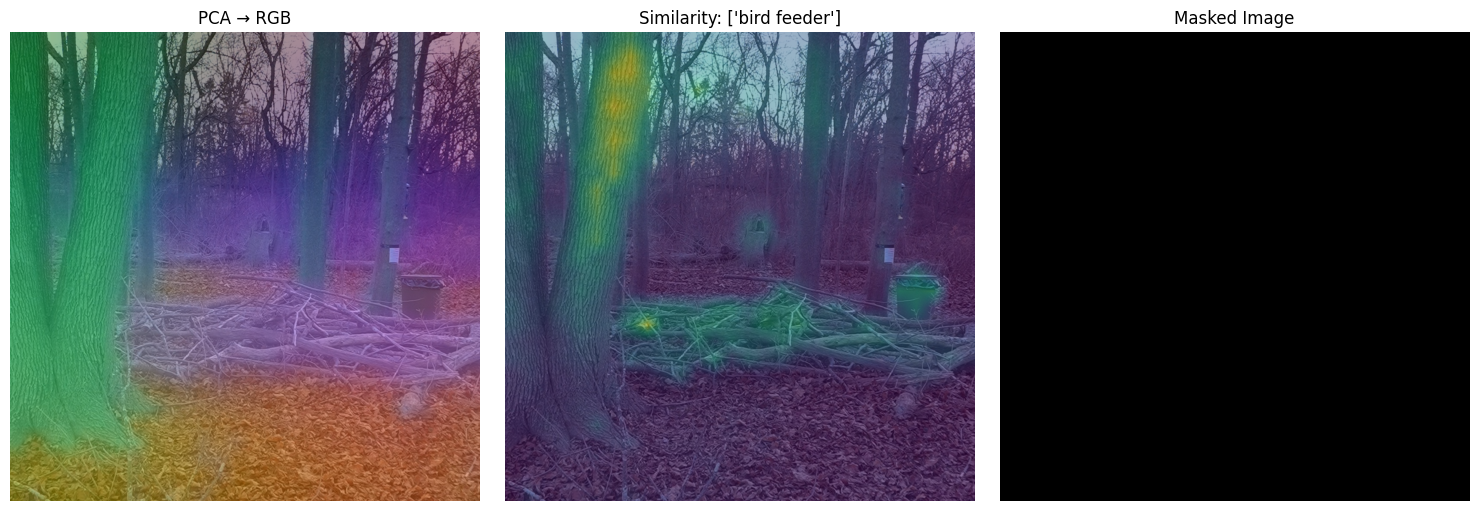

In [9]:
positive = ["bird feeder"]
negative = ["ground"]

# forward() returns (D, pH, pW) — spatial layout directly
features_t2d = extractor_t2d.forward([frame])  # pass original — forward re-crops

sim_t2d = extractor_t2d.score_queries(
    features_t2d[0], positive=positive, negative=negative, temperature=0.05
)
# sim_t2d: (pH, pW) — ready for visualization

sq_frame = np.array(extractor_t2d.preprocess(frame))  # use cropped frame to match sim_map dims

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(pca_to_rgb(features_t2d[0], sq_frame))
axes[0].set_title("PCA → RGB")
axes[1].imshow(compute_heatmap(sq_frame, sim_t2d))
axes[1].set_title(f"Similarity: {positive}")
axes[2].imshow(compute_masked_image(sq_frame, sim_t2d))
axes[2].set_title("Masked Image")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


## MaskCLIP vs Talk2DINO Comparison

Side-by-side feature comparison on the same image.
MaskCLIP uses the full frame; Talk2DINO uses the center-cropped square (center-crop is required by the model).

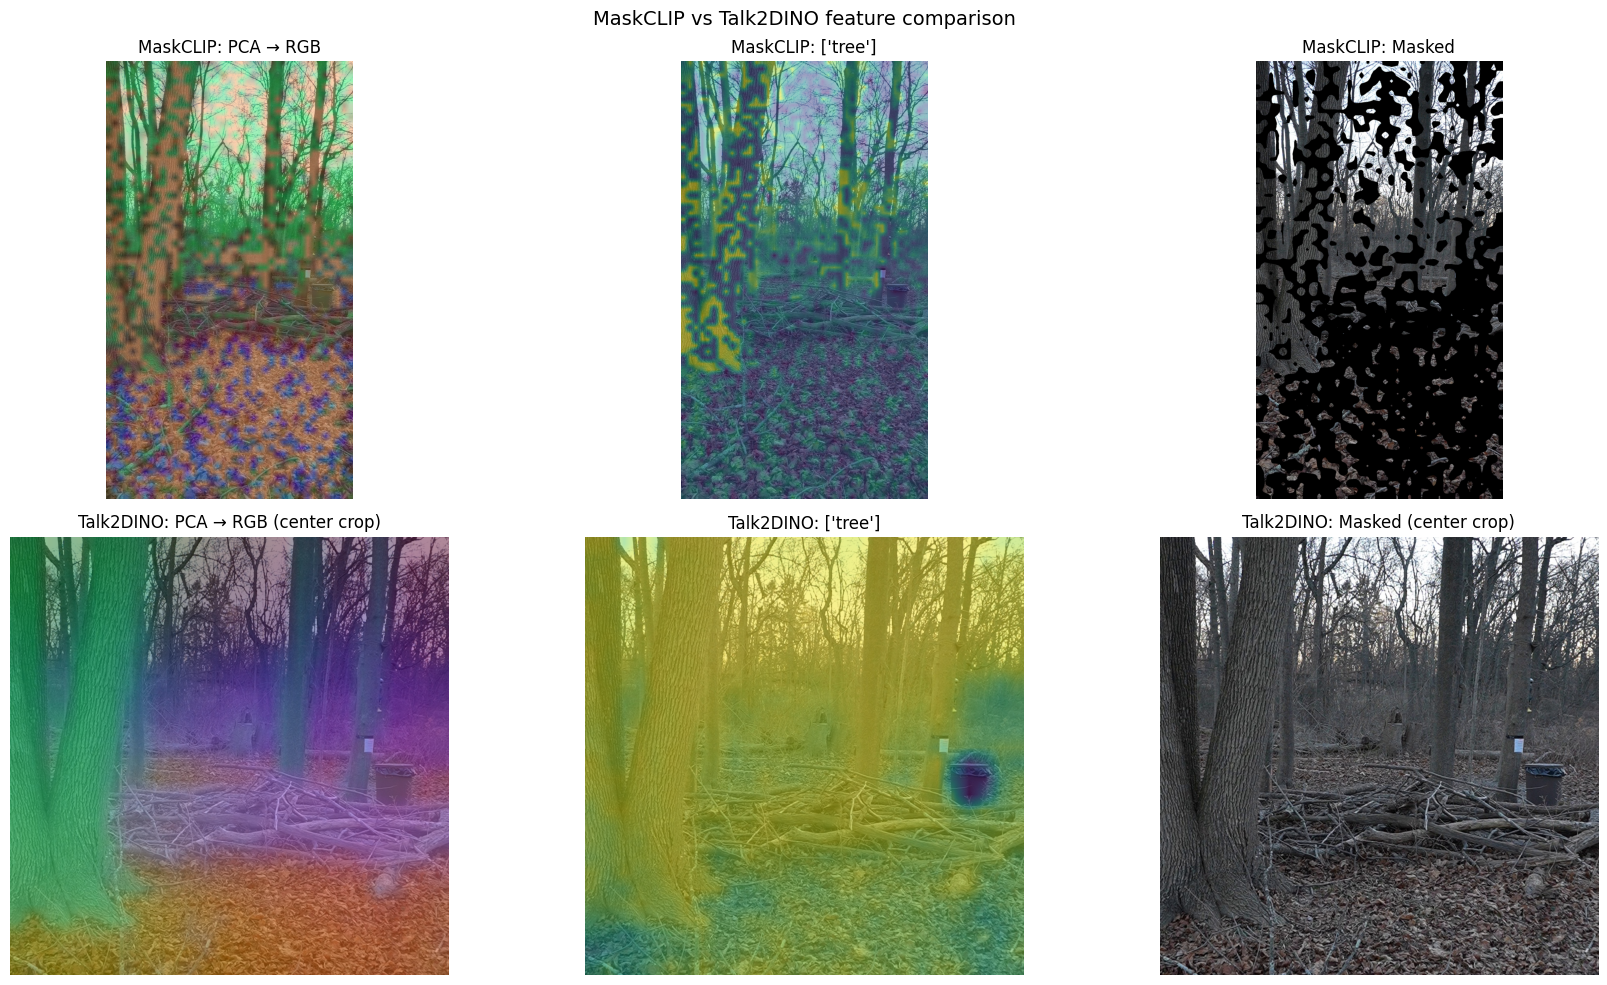

In [10]:
# Re-score with the same query for fair comparison
QUERY_POSITIVE = ["tree"]
QUERY_NEGATIVE = ["object"]

sim_clip = extractor_clip.score_queries(
    features_clip[0], positive=QUERY_POSITIVE, negative=QUERY_NEGATIVE
)
sim_t2d_cmp = extractor_t2d.score_queries(
    features_t2d[0], positive=QUERY_POSITIVE, negative=QUERY_NEGATIVE
)
sq_frame = np.array(extractor_t2d.preprocess(frame))  # cropped frame for t2d viz

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].imshow(pca_to_rgb(features_clip[0], frame))
axes[0, 0].set_title("MaskCLIP: PCA → RGB")
axes[0, 1].imshow(compute_heatmap(frame, sim_clip))
axes[0, 1].set_title(f"MaskCLIP: {QUERY_POSITIVE}")
axes[0, 2].imshow(compute_masked_image(frame, sim_clip))
axes[0, 2].set_title("MaskCLIP: Masked")

axes[1, 0].imshow(pca_to_rgb(features_t2d[0], sq_frame))
axes[1, 0].set_title("Talk2DINO: PCA → RGB (center crop)")
axes[1, 1].imshow(compute_heatmap(sq_frame, sim_t2d_cmp))
axes[1, 1].set_title(f"Talk2DINO: {QUERY_POSITIVE}")
axes[1, 2].imshow(compute_masked_image(sq_frame, sim_t2d_cmp))
axes[1, 2].set_title("Talk2DINO: Masked (center crop)")

for ax in axes.flat:
    ax.axis("off")
plt.suptitle("MaskCLIP vs Talk2DINO feature comparison", fontsize=14)
plt.tight_layout()
plt.show()